### **Does globally optimised mult-agent routing via Genetic Algorithms produce better evacuation outcomes than individual greedy path routing?**
#### *And under what conditions does the greedy path selection fail?*

**Hypothesis**
<br>
Allowing all agents to follow the best path will result in congested nodes resulting in delays as the greedy algorithm can only focus on the path and not the wider population level congestion. The genetic algorithm will inherently account for this collective congestion in its fitness function and is likely a realistic approximation for real life if people where to communicate in evacuation situations (i.e. use different exits rather than the shortest one).

In [1]:
%load_ext autoreload
%autoreload 2

#### Environment Set Up
***

In [2]:
import numpy as np
from tqdm import tqdm

from utils.environment import Environment 
from multi_agent_ga import simulate_ga_evacuation, simulate_greedy_evacuation
from utils.algorithm_evaluation import AlgorithmComparison

Small city graph has 10 starting points and 6 exit points with a bottleneck score of 0.195


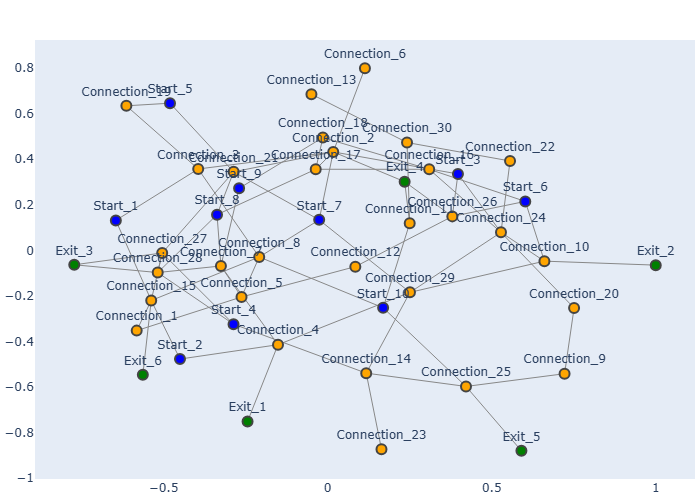

In [3]:
city_name = "small_city_graph"
city = Environment(city_name=city_name)
city.summarise_city()



> **Max betweenness < 0.1**  → well connected, no dominant bottleneck
<br>
> **Max betweenness 0.1-0.3** → moderate bottleneck, some critical junctions
<br>
> **Max betweenness > 0.3**  → severe bottleneck, network heavily dependent on few nodes

In the following experiements the scenarios represent individual agents with the following characteristics:
* Walking speed - some agents walk faster/slower than other agents.
* Each agent has their own starting position (this does not vary between the genetic algorithm and greedy algorithm) # TODO: Check this...
* Each agent is considered an "individual" they have no connection to any other agent - i.e. no agents need to stay with each other like families.

The following cell defines the number of experiements which should be run for comparison and defines the random seeds which will be used across both experiments - this ensures the agents have the same start point in the city.

In [4]:
n_experiments = 30

rng = np.random.default_rng(42)
algorithm_seeds = rng.integers(0, 10**6, size=n_experiments)

num_agents = 50
simulation_params = {"congestion": True, "walking": False, "fitness": "max"}

#### Example Greedy Algorithm
***
The below code shows how the greedy algorithm works - producing the final output metrics for this scenario.

In [5]:
greedy_solution, greedy_evaluation = simulate_greedy_evacuation(
    num_agents=num_agents,
    simulation_params=simulation_params,
    algorithm_seed=algorithm_seeds[0],
    city=city,
    verbose=True
)



==================================================================================== FINAL RESULTS ====================================================================================
Avg path length: 3.24 | Total time: 27.00 | Average time: 12.28 | Congestion index: 74% | Avg Congestion delay: 9.04 | Exit utilisation: 0.30 | Avg Path Efficiency: 1.00


#### Genetic Algorithm
***
The below code shows how the genetic algorithm works - producing metrics showing the performance of the evolutions over time (if you want to see every evolution set `verbose` to 1) as well as the final output metrics for this scenario.

In [6]:
ga_solution, ga_evaluation = simulate_ga_evacuation(
    city=city,
    num_agents=num_agents,
    population_size=50,
    algorithm_seed=algorithm_seeds[0],
    max_evolutions=50,
    simulation_params={"congestion": True, "walking": False, "fitness": "max"},
    verbose=5,
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: small_city_graph | Population size: 50 | Walking Speed: 1.0
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 15.000 | avg fit: 18.060 | worst fit: 27.000 | avg path: 6.612 | congestion: 1.992 | exit use: 0.352 | diveristy: 0.062
Evolution    5 | best fit: 15.000 | avg fit: 18.860 | worst fit: 24.000 | avg path: 6.949 | congestion: 2.014 | exit use: 0.336 | diveristy: 0.241
Evolution   10 | best fit: 14.000 | avg fit: 18.220 | worst fit: 22.000 | avg path: 7.133 | congestion: 1.958 | exit use: 0.328 | diveristy: 0.376
Evolution   15 | best fit: 13.000 | avg fit: 18.480 | worst fit: 27.000 | avg path: 7.232 | congestion: 1.909 | exit use: 0.322 | diveristy: 0.443
Evolution   20 | best fit: 13.000 | avg fit

#### Simulations
***
The below code is to compare the outputs of both algorithms over multiple scenarios.
TODO: at the mo this is only for one city need to come back and try different ones.

In [ ]:
greedy_outputs = []
ga_outputs = []
for seed_idx in tqdm(range(n_experiments)):
    
    _ , greedy_evaluation = simulate_greedy_evacuation(
        num_agents=num_agents,
        simulation_params=simulation_params,
        algorithm_seed=algorithm_seeds[seed_idx],
        city=city,
        verbose=False
    )
    greedy_outputs.append(greedy_evaluation)
    
    _ , ga_evaluation = simulate_ga_evacuation(
        city=city,
        num_agents=num_agents,
        population_size=50,
        algorithm_seed=algorithm_seeds[seed_idx],
        max_evolutions=50,
        simulation_params=simulation_params,
        verbose=0,
    )
    ga_outputs.append(ga_evaluation) 
    


100%|██████████| 30/30 [1:40:42<00:00, 201.41s/it]


We will compare the following metrics:

* Total evacuation time — is there a statistically significant difference between the time the last agent exits under GA vs greedy? A significant result here is the main finding - the GA either gets everyone out faster or slower overall.

* Average evacuation time — is there a significant difference in typical agent experience? This is more robust than total time because it's less sensitive to a single slow agent skewing the result. If total time differs but average doesn't, one or two agents are driving the difference rather than the whole population.

* Average congestion delay — is the GA significantly reducing the delays agents experience due to overcrowding? This directly tests whether global route optimisation is actually redistributing agents away from bottlenecks. A significant reduction here is the mechanistic explanation for why GA beats greedy — not just that it's faster, but specifically because it reduces congestion.

* Exit utilisation — is there a significant difference in how evenly agents are distributed across exits? This is your core behavioural claim — that greedy causes everyone to crowd the nearest exit while GA spreads agents more evenly. A significant result here confirms the fundamental difference in routing behaviour between the two approaches.

* Average path efficiency — are GA agents taking significantly longer routes than greedy agents? A significant result here combined with better evacuation time tells your central story — GA agents travel less efficiently individually but produce better collective outcomes, which is the price of coordination and the answer to your research question.

In [8]:
experiment_setup = f'For {city_name.replace("_", " ").capitalize()} with {num_agents} agents across {n_experiments} experiements'
print(experiment_setup)
print('='*len(experiment_setup))

For Small city graph with 50 agents across 30 experiements


In [9]:
comparison = AlgorithmComparison(greedy_outputs=greedy_outputs, ga_outputs=ga_outputs)
results = comparison.statistical_tests(verbose=True)

Total time p-value: 0.000 (Significant: True)
Average time p-value: 0.000 (Significant: True)
Avg Congestion delay p-value: 0.000 (Significant: True)
Exit utilisation p-value: 0.015 (Significant: True)
Avg Path Efficiency p-value: 0.000 (Significant: True)


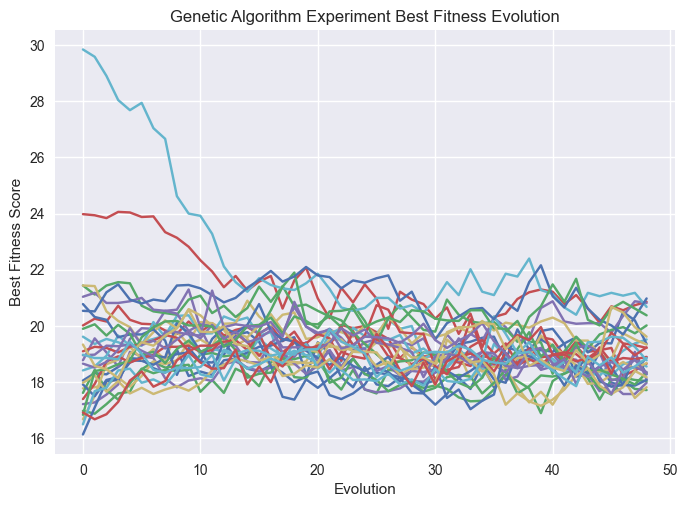

In [10]:
comparison.ga_convergence_plots()


The Price of Anarchy (PoA) quantifies the cost of selfish behaviour - specifically, how much 
worse evacuation performance is when every agent acts greedily compared to globally optimised 
routing. A PoA of 1.5 means greedy routing takes 50% longer than the GA solution.

By comparing PoA against each city's betweenness centrality, we test whether the cost of 
selfish behaviour scales with network bottleneck severity. The hypothesis is that cities with 
high betweenness centrality (few critical junctions that all shortest paths pass through) will 
show higher PoA.

In [ ]:
price_of_anarachy = comparison.price_of_anarchy(verbose=True, city=city)

This compares how agents are distributed across available exits under each approach. Greedy 
routing is expected to cluster agents at the nearest or most obvious exits, producing uneven 
utilisation. The GA, optimising globally, should naturally distribute agents more evenly to 
reduce congestion at individual exits.

In [ ]:
comparison.exit_utilisation(city_name=city_name)

This breaks down evacuation performance by where agents begin, rather than reporting a single 
population average. Some start locations are closer to exits or better connected, so average 
times will naturally vary.

In [ ]:
comparison.exit_time_by_start_location()